In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import nltk
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

In [192]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\BHATTI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [193]:
nltk.download('punkt', download_dir='nltk_data')
import os
nltk.data.path.append(os.path.abspath("nltk_data"))

[nltk_data] Downloading package punkt to nltk_data...


[nltk_data]   Package punkt is already up-to-date!


In [194]:
from nltk.tokenize import word_tokenize, sent_tokenize

In [195]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\BHATTI\AppData\Roaming\nltk_data...


[nltk_data]   Package punkt is already up-to-date!


True

In [196]:
df = pd.read_csv('spam.csv', encoding='latin1')

In [197]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [198]:
Unnamed = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
df = df.drop(columns = Unnamed)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [199]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [200]:
df.describe()

,v1,v2
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [201]:
df['v1'].value_counts()

v1
ham     4825
spam     747
Name: count, dtype: int64

In [202]:
le = LabelEncoder()
df['v1'] = le.fit_transform(df['v1'])

In [203]:
df.head()

,v1,v2
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [204]:
df.duplicated().sum()

np.int64(403)

In [205]:
df= df.drop_duplicates()

In [206]:
df.shape

(5169, 2)

In [207]:
df['chars'] = df['v2'].apply(len)

In [124]:
df['words'] = df['v2'].apply(lambda x: len(word_tokenize(x)))

In [125]:
df['sents'] = df['v2'].apply(lambda x: len(sent_tokenize(x)))

In [126]:
df.head()

,v1,v2,chars,words,sents
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [127]:
df[df['v1'] == 0][['chars', 'words', 'sents']].describe()

,chars,words,sents
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [128]:
df[df['v1'] == 1][['chars', 'words', 'sents']].describe()

,chars,words,sents
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


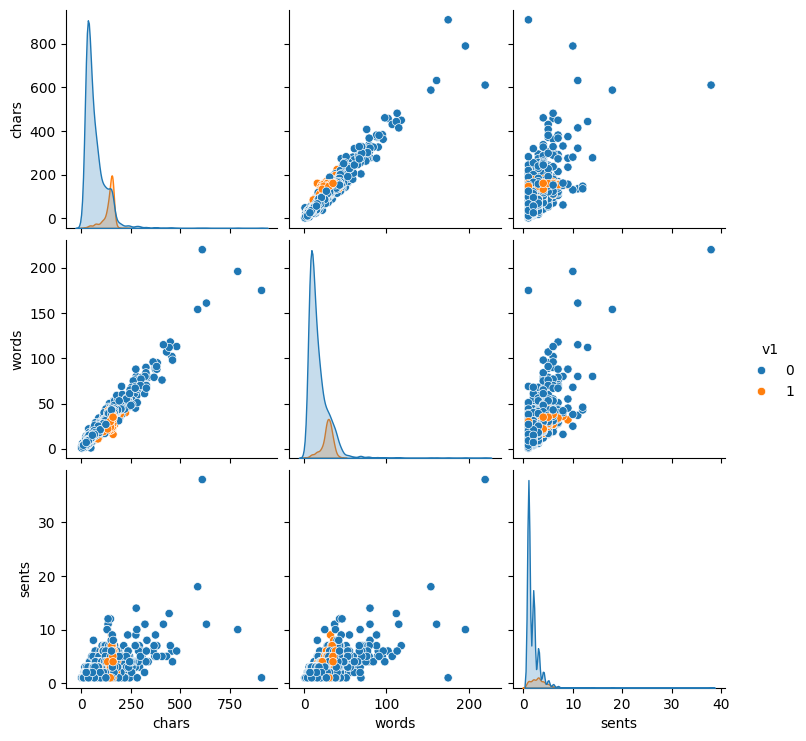

In [129]:
import seaborn as sns
sns.pairplot(df, hue='v1')

In [ ]:
df.drop(columns=['v2']).corr()


,v1,chars,words,sents
v1,1.000000,0.384717,0.262912,0.263939
chars,0.384717,1.000000,0.965760,0.624139
words,0.262912,0.965760,1.000000,0.679971
sents,0.263939,0.624139,0.679971,1.000000


In [147]:
df.head()

,v1,v2,chars,words,sents
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [131]:
ps = PorterStemmer()

In [151]:
def transformText(text):
    if text is None:
        return ""

    text = str(text).lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))
        
    return " ".join(y)

In [152]:
df['Text'] = df['v2'].apply(transformText)

In [162]:
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')
spam_wc = wc.generate(df[df['v1'] == 1]['Text'].str.cat(sep=" "))

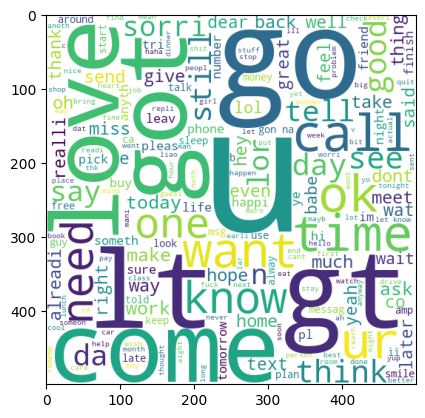

In [167]:
plt.Figure(figsize=(15,8))
plt.imshow(spam_wc)

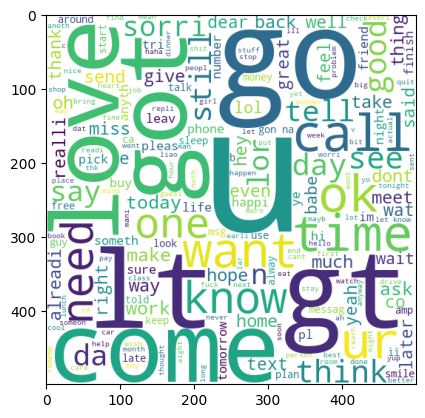

In [166]:
ham_wc = wc.generate(df[df['v1'] == 0]['Text'].str.cat(sep=" "))
plt.Figure(figsize=(15,8))
plt.imshow(ham_wc)

In [168]:
spam_corpus = []
for msg in df[df['v1'] == 1]['Text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [169]:
spam_corpus

['free',
 'entri',
 '2',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 '21st',
 'may',
 'text',
 'fa',
 '87121',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 '08452810075over18',
 'freemsg',
 'hey',
 'darl',
 '3',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'kl341',
 'valid',
 '12',
 'hour',
 'mobil',
 '11',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 '08002986030',
 'six',
 'chanc',
 'win',
 'cash',
 '100',
 'pound',
 'txt',
 'csh11',
 'send',
 'cost',
 '6day',
 'tsandc',
 'appli',
 'repli',
 'hl',
 '4',
 'info',
 'urgent',
 '1',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 '81010',
 'c',
 'lccltd',
 'pobox',
 '4403ldnw

<Axes: ylabel='1'>

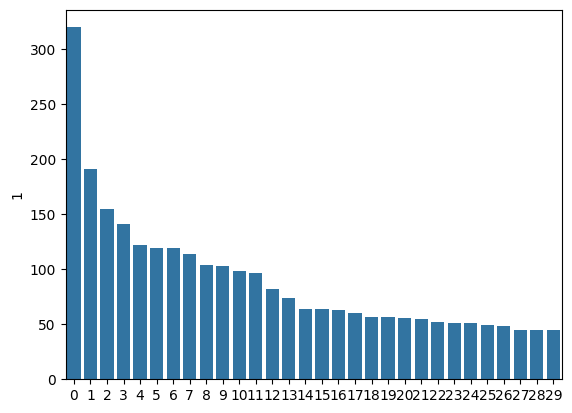

In [179]:
sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30))[1])

In [183]:
ham_corpus = []
for msg in df[df['v1'] == 1]['Text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [184]:
ham_corpus

['free',
 'entri',
 '2',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 '21st',
 'may',
 'text',
 'fa',
 '87121',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 '08452810075over18',
 'freemsg',
 'hey',
 'darl',
 '3',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'kl341',
 'valid',
 '12',
 'hour',
 'mobil',
 '11',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 '08002986030',
 'six',
 'chanc',
 'win',
 'cash',
 '100',
 'pound',
 'txt',
 'csh11',
 'send',
 'cost',
 '6day',
 'tsandc',
 'appli',
 'repli',
 'hl',
 '4',
 'info',
 'urgent',
 '1',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 '81010',
 'c',
 'lccltd',
 'pobox',
 '4403ldnw

<Axes: ylabel='0'>

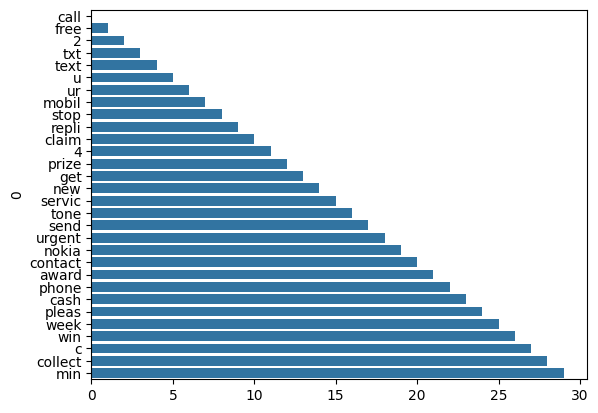

In [ ]:
sns.barplot(pd.DataFrame(Counter(ham_corpus).most_common(30))[0])

In [187]:
cv = CountVectorizer()
X = cv.fit_transform(df['Text']).toarray()

In [188]:
X.shape

(5169, 6708)

In [ ]:
y = df['v1'].values

KeyError: 'V1'

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)